# Automatic 3D anchor localization from pairwise distances

Estimate the 3D coordinates of $N$ anchors from a noisy $N \times N$ matrix of
pairwise distances $D_{ij} = \|x_i - x_j\| + \epsilon_{ij}$ with
$\epsilon_{ij} \sim \mathcal{N}(0, \sigma^2)$. Algorithm and helpers live in
[anchor_cal.py](anchor_cal.py); this notebook is a thin runner that imports
them and exercises the pipeline.

## 7-Degree Of Freedom ambiguity

Pairwise distances are *invariant* under any rigid motion + reflection of the
configuration: translating, rotating, or mirror-flipping the anchor set leaves
every $\|x_i - x_j\|$ unchanged. So the data only determines $X$ up to **7
degrees of freedom**: 3 translation + 3 rotation + 1 reflection. The estimator
returns *some* configuration consistent with the distances; matching it to a
known frame requires either an external reference (`procrustes_align`, used
here for evaluation) or a deterministic frame convention (`gauge_fix`, used
in deployment when no ground truth is available).

## Algorithm pipeline (`anchor_cal.py`)

1. **Closed-form initial guess** (`mds_init`) —  minimizes the squared-distance error
$\|D^2(\hat X) - D^2_{\text{meas}}\|_F^2$. Robust to mild noise; gets us into the basin of attraction of the
   global minimum.

2. **Weighted nonlinear LS** (`estimate_positions`) — Levenberg-Marquardt on
   the residuals $r_{ij} = (\|x_i - x_j\| - D_{ij}) / \sigma_{ij}$. Converges to the maximum-likelihood estimator under Gaussian range noise.

3. **Frame fixing** - `gauge_fix`: pins a deterministic frame using four reference anchors
     (origin, +x axis, xy-plane with $y > 0$, $z > 0$).

## Anchor placement constraints

Estimator accuracy is dominated by anchor geometry:

- **Hard:** $N \geq 4$ in 3D, anchors must not all be coplanar
- **`gauge_fix` preconditions:** `ref[0..3]` must be non-coplanar (in
  successive ranks: `ref[1] ≠ ref[0]`, `ref[2]` not on the line through
  `ref[0..1]`, `ref[3]` not in the plane of `ref[0..2]`).

## Imports

Pull the algorithm and demo helpers out of [anchor_cal.py](anchor_cal.py).
Underscored names are intentionally imported — they're "private to the .py"
but are the natural orchestration handles for a notebook.

In [8]:
import numpy as np
from anchor_cal import (
    mds_init, estimate_positions, procrustes_align, gauge_fix,
    _simulate, _rmse, _noisy_distances, _scenario_sweep,
)

---

## How `mds_init` works — deriving the closed-form initial guess

Given the noisy pairwise-distance matrix $D$ (with $D_{ij} = \|x_i - x_j\|$
plus noise), classical MDS recovers a 3D point configuration in **a single
eigendecomposition** — no iteration. Here's how the formula
$B = -\tfrac{1}{2}\,J D^2 J$ comes about.

### Notation

- $\mathbf{1} \in \mathbb{R}^N$ — the **all-ones column vector**: every entry
  equal to $1$. Bold to distinguish from the scalar $1$.
- $\mathbf{1}\mathbf{1}^\top \in \mathbb{R}^{N \times N}$ — the **all-ones
  matrix**, formed by the outer product. Every entry equals $1$; rank 1,
  with $\mathbf{1}$ as its only non-zero eigenvector (eigenvalue $N$).

The "double-centering" operator below is $J = I - \tfrac{1}{N}\mathbf{1}\mathbf{1}^\top$;
it subtracts the constant component from any vector or matrix it acts on.

### Step 1 — squared distances expand into a Gram-matrix identity

For any two points,

$$
D_{ij}^2 \;=\; \|x_i - x_j\|^2 \;=\; \|x_i\|^2 \;+\; \|x_j\|^2 \;-\; 2\,x_i \cdot x_j.
$$

Let $g \in \mathbb{R}^N$ have entries $g_i = \|x_i\|^2$. In matrix form,

$$
D^2 \;=\; g\,\mathbf{1}^\top \;+\; \mathbf{1}\,g^\top \;-\; 2\,X X^\top.
$$

The **Gram matrix** $G = X X^\top$ contains every pairwise dot product
$x_i \cdot x_j$. If we could isolate $G$ we'd be done — its
eigendecomposition gives $X$ directly.

### Step 2 — the double-centering trick

The two unwanted terms $g\,\mathbf{1}^\top$ and $\mathbf{1}\,g^\top$ are
*rank-1 along the constant direction*. Killing them is exactly what the
**centering matrix**

$$
J \;=\; I \;-\; \tfrac{1}{N}\,\mathbf{1}\mathbf{1}^\top
$$

does: $J\mathbf{1} = 0$ and (by symmetry) $\mathbf{1}^\top J = 0$.
Multiply $D^2$ by $J$ from both sides:

$$
J D^2 J \;=\;
\underbrace{J\,g\,\mathbf{1}^\top J}_{=\,0\;(\mathbf{1}^\top J = 0)} \;+\;
\underbrace{J\,\mathbf{1}\,g^\top J}_{=\,0\;(J\mathbf{1} = 0)} \;-\;
2\,J X X^\top J.
$$

For the third term, force $X$ to be **centered** ($\mathbf{1}^\top X = 0$
— this is the gauge choice classical MDS makes; pins 3 of the 7 DOF). Then
$JX = X$ and $X^\top J = X^\top$, so $J X X^\top J = X X^\top = G$.

The unwanted terms vanish; only the Gram matrix survives:

$$
\boxed{\,B \;=\; -\tfrac{1}{2}\,J D^2 J \;=\; X X^\top \;=\; G\,}
$$

That's the line `B = -0.5 * J @ D2 @ J` in
[anchor_cal.py:38](anchor_cal.py#L38).

### Step 3 — eigendecomposition recovers $X$

$G = X X^\top$ is symmetric positive-semidefinite of rank 3 (since $X$
has 3 columns). Its eigendecomposition is

$$
G \;=\; U\,\Lambda\,U^\top, \qquad
\Lambda = \mathrm{diag}(\lambda_1, \lambda_2, \lambda_3, 0, \dots, 0),
\quad \lambda_1 \ge \lambda_2 \ge \lambda_3 \ge 0.
$$

### Step 4 — handling noise

With Gaussian range noise on $D$, the recovered $B$ is no longer truly
rank-3 PSD: the trailing eigenvalues drift away from zero, and a few may
even go *negative*. The implementation handles this in two places:

- **Take only the top 3** eigenpairs — the rest are noise.
- **Clip negatives to zero** before the square root
  (`L = np.maximum(eigvals[idx], 0.0)` at
  [anchor_cal.py:43](anchor_cal.py#L43)). Otherwise `np.sqrt` would emit
  a `RuntimeWarning` or produce NaN.

The result minimizes the squared-distance error
$\|D^2(\hat X) - D^2_{\text{meas}}\|_F^2$ — *not* the MLE under Gaussian
noise on $D$ (LM does that next), but close enough to land in the global
basin of attraction with high probability.

---

## How `estimate_positions` works

Given measured pairwise distances $D_{ij}$ and per-pair noise $\sigma_{ij}$,
the estimator returns the $N \times 3$ coordinate matrix $X$ that maximizes
the likelihood of the measurements.

### Maximum-likelihood objective

Each range measurement is modelled as
$D_{ij} = \|x_i - x_j\| + \epsilon_{ij}$ with
$\epsilon_{ij} \sim \mathcal{N}(0, \sigma_{ij}^2)$, independently across pairs.
The joint likelihood of the measurements given the configuration $X$ is the
product of Gaussian PDFs:

$$
p\bigl(\{D_{ij}\}_{i<j} \,\big|\, X\bigr) \;=\; \prod_{i<j}
  \frac{1}{\sqrt{2\pi}\,\sigma_{ij}}\;
  \exp\!\left(-\,\frac{\bigl(\|x_i - x_j\| - D_{ij}\bigr)^2}{2\,\sigma_{ij}^2}\right).
$$

Taking $-\log$ and dropping terms that don't depend on $X$, the
maximum-likelihood estimate is the minimizer of the weighted sum of squared
residuals:

$$
\hat X \;=\; \arg\min_X \mathcal{L}(X), \qquad
\mathcal{L}(X) \;=\; -\log p\bigl(\{D_{ij}\}\,\big|\,X\bigr) + \text{const}
\;=\; \tfrac{1}{2}\sum_{i<j}
  \frac{\bigl(\|x_i - x_j\| - D_{ij}\bigr)^2}{\sigma_{ij}^2}.
$$

`estimate_positions` reformulates this as a vector-valued nonlinear
least-squares problem with residuals
$r_{ij}(X) = w_{ij}\bigl(\|x_i - x_j\| - D_{ij}\bigr)$ where
$w_{ij} = 1/\sigma_{ij}$, and hands it to
`scipy.optimize.least_squares`.

## Single-shot sanity check

Four anchors placed at positions:

- `ref[0]` $= (0,\, 0,\, 0)$ — origin
- `ref[1]` $= (X,\, 0,\, 0)$ — on $+x$ axis
- `ref[2]` $= (X/2,\, Y,\, 0)$ — in xy-plane with $y > 0$
- `ref[3]` $= (X/2,\, Y/2,\, Z)$ — has $z > 0$

The cell computes both estimates at $\sigma = 0.1$ m using `estimate_positions`:

- **Closed form only** — `estimate_positions(D_meas, sigma, polish=False)`
  returns just the MDS init (Step 3 of the derivation above), no LM step.
- **Closed form + LM** — `estimate_positions(D_meas, sigma, polish=True)`
  (the default) runs trust-region LM on top of the MDS init to reach the
  Gaussian-noise MLE.

The per-anchor table at the end shows ground truth, MDS-only estimate,
and MDS+LM estimate **side-by-side** for direct visual comparison.

In [9]:
# Cuboid: 8 corners of an edge-L cube with one vertex at the origin —
# coordinates are non-negative, relative to origin. The FIRST 4 ANCHORS
# are the canonical-form reference set for gauge_fix (origin + a path
# along the cube edges; non-coplanar tetrahedron with volume L^3 / 6).
# The remaining 4 corners ride along under the same gauge transformation.

X, Y, Z = 10.0, 20.0, 15.0

sigma = 0.3
X_true = np.array([
    # ref[0..3]: canonical-form reference anchors (in canonical positions)
    [0, 0, 0],   # ref[0] -> origin
    [X, 0, 0],   # ref[1] -> on +x axis              (a = L != 0)
    [X/2, Y, 0],   # ref[2] -> in xy-plane with y > 0  (c = L != 0)
    [X/2, Y/2, Z],   # ref[3] -> has z > 0               (f = L != 0)
], dtype=float)
N = len(X_true)
D_meas = _noisy_distances(X_true, sigma, seed=1337)

# Closed-form MDS init only (polish=False)
X_mds_raw, _ = estimate_positions(D_meas, sigma=sigma, polish=False)
X_mds = gauge_fix(X_mds_raw)

# MDS init + LM polish (polish=True, the default)
X_lm_raw, res = estimate_positions(D_meas, sigma=sigma, polish=True)
X_lm = gauge_fix(X_lm_raw)

print(f"N = {N}, sigma = {sigma}")
print(f"MDS-only RMSE  (closed form) : {_rmse(X_mds, X_true):.4f}")
print(f"MDS + LM RMSE  (polished)    : {_rmse(X_lm,  X_true):.4f}")
print(f"LM iterations                : {res.nfev}")
print(f"LM final cost (½‖r‖²)        : {res.cost:.4f}")

# Side-by-side per-anchor estimates
print()
print("Per-anchor estimates (gauge-fixed):")
print("    i        true (x, y, z)                MDS only                       MDS + LM")
for i, (t, m, l) in enumerate(zip(X_true, X_mds, X_lm)):
    print(f"   {i:2d}   ({t[0]:+7.3f},{t[1]:+7.3f},{t[2]:+7.3f})   "
          f"({m[0]:+7.3f},{m[1]:+7.3f},{m[2]:+7.3f})   "
          f"({l[0]:+7.3f},{l[1]:+7.3f},{l[2]:+7.3f})")


N = 4, sigma = 0.3
MDS-only RMSE  (closed form) : 0.3303
MDS + LM RMSE  (polished)    : 0.3303
LM iterations                : 1
LM final cost (½‖r‖²)        : 0.0000

Per-anchor estimates (gauge-fixed):
    i        true (x, y, z)                MDS only                       MDS + LM
    0   ( +0.000, +0.000, +0.000)   ( +0.000, +0.000, +0.000)   ( +0.000, +0.000, +0.000)
    1   (+10.000, +0.000, +0.000)   (+10.449, -0.000, +0.000)   (+10.449, -0.000, +0.000)
    2   ( +5.000,+20.000, +0.000)   ( +4.700,+20.074, -0.000)   ( +4.700,+20.074, -0.000)
    3   ( +5.000,+10.000,+15.000)   ( +5.050, +9.664,+14.846)   ( +5.050, +9.664,+14.846)


### Wireframe overlay — gauge ambiguity, visually

Plot the wireframe (all  pairwise edges) for:

- **`X_true`** — ground truth.
- **`X_mds`** — raw MDS output, in *its own* frame. Should look like a
  translated, rotated, possibly reflected copy of `X_true`. That offset is
  the 7-DOF gauge ambiguity made visible.
- **`X_mds_aligned`** — `X_mds` after `procrustes_align(..., X_true)`. Should
  overlap `X_true` to within the noise — Procrustes pins the rigid motion +
  reflection.

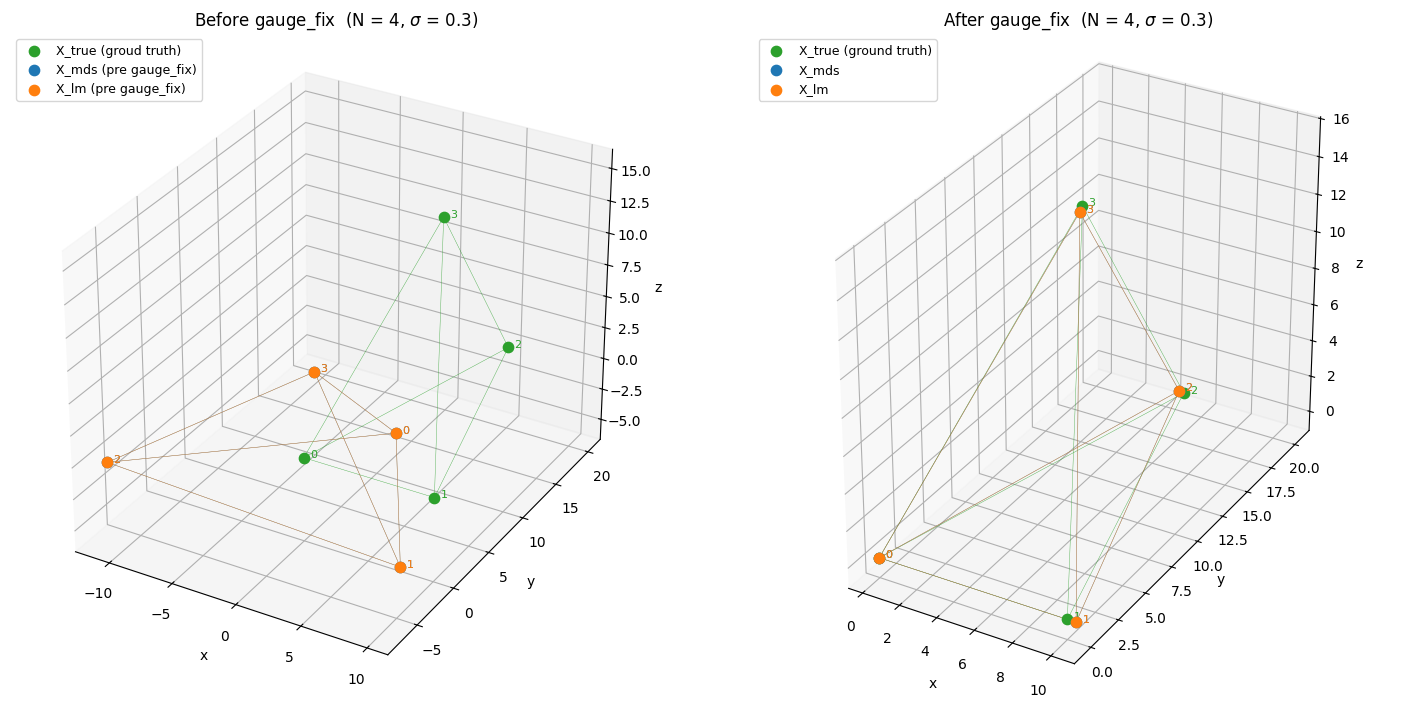

In [10]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 — registers 3d projection

def plot_wireframe(ax, X, color, label, alpha=0.85):
    n = X.shape[0]
    for i in range(n):
        for j in range(i + 1, n):
            ax.plot(
                [X[i, 0], X[j, 0]],
                [X[i, 1], X[j, 1]],
                [X[i, 2], X[j, 2]],
                color=color, alpha=alpha, linewidth=0.3,
            )
    ax.scatter(X[:, 0], X[:, 1], X[:, 2], color=color, s=55,
               label=label, depthshade=False)
    for k in range(n):
        ax.text(X[k, 0], X[k, 1], X[k, 2], f'  {k}', color=color, fontsize=8)


fig = plt.figure(figsize=(15, 7))

# Left: BEFORE gauge_fix — raw estimates in their respective frames.
# X_true is shown as reference; the raw estimates (X_mds_raw, X_lm_raw)
# live in MDS-centered frames and so are translated/rotated/possibly
# reflected vs X_true.
ax_pre = fig.add_subplot(121, projection='3d')
plot_wireframe(ax_pre, X_true,     'C2', 'X_true (groud truth)')
plot_wireframe(ax_pre, X_mds_raw,  'C0', 'X_mds (pre gauge_fix)')
plot_wireframe(ax_pre, X_lm_raw,   'C1', 'X_lm (pre gauge_fix)')
all_pre = np.vstack([X_true, X_mds_raw, X_lm_raw])
ax_pre.set_box_aspect(np.ptp(all_pre, axis=0))
ax_pre.set_xlabel('x')
ax_pre.set_ylabel('y')
ax_pre.set_zlabel('z')
ax_pre.set_title(f'Before gauge_fix  (N = {len(X_true)}, $\\sigma$ = {sigma})')
ax_pre.legend(loc='upper left', fontsize=9)

# Right: AFTER gauge_fix — all three configurations in the same canonical frame.
ax_post = fig.add_subplot(122, projection='3d')
plot_wireframe(ax_post, X_true, 'C2', 'X_true (ground truth)')
plot_wireframe(ax_post, X_mds,  'C0', 'X_mds')
plot_wireframe(ax_post, X_lm,   'C1', 'X_lm')
all_post = np.vstack([X_true, X_mds, X_lm])
ax_post.set_box_aspect(np.ptp(all_post, axis=0))
ax_post.set_xlabel('x')
ax_post.set_ylabel('y')
ax_post.set_zlabel('z')
ax_post.set_title(f'After gauge_fix  (N = {len(X_true)}, $\\sigma$ = {sigma})')
ax_post.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

## Random-anchor Monte-Carlo: closed form vs LM polish, RMSE vs measurement noise

For each $N \in \{4, 10, 16\}$ and each $\sigma$ on a log-spaced grid
($\sigma \in [0.01, 1.0]$ m, 8 points), run $T = 32$ trials. Each trial:

1. **Place the first 4 anchors in canonical form** on a cube of side 10:
   $(0, 0, 0)$, $(10, 0, 0)$, $(5, 10, 0)$, $(5, 5, 10)$. This guarantees
   the `gauge_fix` non-coplanar tetrahedron requirement (volume
   $= \tfrac{1}{6}\cdot 10^3 \approx 167$).
2. **For $N > 4$**, place the remaining anchors uniformly on the **6
   faces of the cube**, sampled proportional to face area (so each face
   is equally likely to host an anchor on a non-cube cuboid; equally
   likely on the cube here since all faces have the same area).
3. **Generate the noisy distance matrix** $D_{\text{meas}}$ at the given
   $\sigma$.
4. **Compute two estimates** via the new `polish` parameter:
   - `estimate_positions(D, sigma, polish=False)` — closed-form MDS
     init only (Step 3 of the MDS derivation).
   - `estimate_positions(D, sigma, polish=True)` — MDS init + LM polish
     (the default, full pipeline).
5. **Pull both estimates and the truth into the same canonical frame**
   via `gauge_fix`, then compute RMSE against truth.

The two side-by-side subplots share their y-axis on log-log:

- **Left**: closed form only (MDS init).
- **Right**: closed form + LM polish.

Each subplot overlays the three $N$ curves. The dashed gray $y = \sigma$
reference shows the "RMSE = noise" baseline; the data should track
$\sigma$ linearly at low noise (slope-1 on log-log).

**What to look for:**

- **LM polish helps more as $N$ grows** — at $N = 4$ (1 redundant
  measurement) the closed form is already the MLE, so LM has nothing to
  do; at $N = 16$ (29 redundant measurements) LM extracts a noticeable
  improvement on the squared-distance MDS estimate.
- **Larger $N$ sits below smaller $N$** in both panels — redundancy
  averaging.
- **The two panels look very similar at small $\sigma$** — both
  estimators agree to within rounding when the data is nearly
  3D-Euclidean (recall the zero-residual derivation: the closed form
  achieves $D^2(\hat X) = D^2_{\text{meas}}$ exactly when the noise
  doesn't push $B$ off the rank-3 PSD cone).

In [11]:
import matplotlib.pyplot as plt

# Monte-Carlo: random anchors per trial, sweep measurement noise sigma.
# First 4 anchors are sampled from the canonical-form parameterization
#   (0, 0, 0), (X, 0, 0), (a, Y, 0), (b, c, Z)
# with uniform cuboid dimensions X, Y, Z in [scale/2, 3*scale/2] (so they
# stay bounded away from zero) and Gaussian off-diagonal offsets a, b, c.
# This guarantees the gauge_fix non-coplanar requirement automatically.
# For N > 4, the remaining anchors are sampled uniformly inside the
# cuboid [0, X] x [0, Y] x [0, Z]. Two N values are run side-by-side.

N_values   = [4, 10, 16]  # number of anchors (4 canonical-form refs + extras)
n_refs     = 4
n_trials   = 32
sigma_grid = np.geomspace(0.01, 1.0, 8)   # log-spaced
scale      = 5.0                          # cuboid dimension scale

# Two result dictionaries: closed-form (MDS init only) and MDS + LM polish.
results_mds = {}  # closed form only
results_lm  = {}  # closed form + LM

for N in N_values:
    rmse_mean_mds = np.zeros_like(sigma_grid)
    rmse_std_mds  = np.zeros_like(sigma_grid)
    rmse_mean_lm  = np.zeros_like(sigma_grid)
    rmse_std_lm   = np.zeros_like(sigma_grid)
    print(f"--- N = {N} ---")
    for k, sigma in enumerate(sigma_grid):
        rmses_mds = np.empty(n_trials)
        rmses_lm  = np.empty(n_trials)
        for t in range(n_trials):
            rng = np.random.default_rng(1000 * t + k)
            X_d, Y_d, Z_d = 10, 10, 10
            X_true     = np.empty((N, 3))
            X_true[0]  = (0,      0,      0)
            X_true[1]  = (X_d,    0,      0)
            X_true[2]  = (X_d/2,  Y_d,    0)
            X_true[3]  = (X_d/2,  Y_d/2,  Z_d)
            if N > n_refs:
                # Extras uniformly distributed on the 6 faces of the cuboid,
                # sampled proportional to face area.
                n_extra = N - n_refs
                dims = np.array([X_d, Y_d, Z_d])
                areas = np.array([dims[1]*dims[2], dims[1]*dims[2],
                                  dims[0]*dims[2], dims[0]*dims[2],
                                  dims[0]*dims[1], dims[0]*dims[1]])
                face_idx = rng.choice(6, size=n_extra, p=areas / areas.sum())
                pts = rng.uniform([0, 0, 0], dims, size=(n_extra, 3))
                axis = face_idx // 2
                side = face_idx % 2
                pts[np.arange(n_extra), axis] = np.where(side == 0, 0.0, dims[axis])
                X_true[n_refs:] = pts

            D_meas = _noisy_distances(X_true, sigma, seed=t)
            X_mds, _ = estimate_positions(D_meas, sigma=sigma, polish=False)
            X_lm,  _ = estimate_positions(D_meas, sigma=sigma, polish=True)
            X_true_fixed = gauge_fix(X_true)
            rmses_mds[t] = _rmse(gauge_fix(X_mds), X_true_fixed)
            rmses_lm[t]  = _rmse(gauge_fix(X_lm),  X_true_fixed)
        rmse_mean_mds[k] = rmses_mds.mean()
        rmse_std_mds[k]  = rmses_mds.std()
        rmse_mean_lm[k]  = rmses_lm.mean()
        rmse_std_lm[k]   = rmses_lm.std()
        print(f"  sigma = {sigma:6.3f}  ->  MDS = {rmse_mean_mds[k]:.4f}, "
              f"MDS+LM = {rmse_mean_lm[k]:.4f}")
    results_mds[N] = (rmse_mean_mds, rmse_std_mds)
    results_lm[N]  = (rmse_mean_lm,  rmse_std_lm)



--- N = 4 ---
  sigma =  0.010  ->  MDS = 0.0111, MDS+LM = 0.0111
  sigma =  0.019  ->  MDS = 0.0214, MDS+LM = 0.0214
  sigma =  0.037  ->  MDS = 0.0412, MDS+LM = 0.0412
  sigma =  0.072  ->  MDS = 0.0796, MDS+LM = 0.0796
  sigma =  0.139  ->  MDS = 0.1536, MDS+LM = 0.1536
  sigma =  0.268  ->  MDS = 0.2961, MDS+LM = 0.2961
  sigma =  0.518  ->  MDS = 0.5708, MDS+LM = 0.5708
  sigma =  1.000  ->  MDS = 1.1026, MDS+LM = 1.1026
--- N = 10 ---
  sigma =  0.010  ->  MDS = 0.0114, MDS+LM = 0.0098
  sigma =  0.019  ->  MDS = 0.0225, MDS+LM = 0.0192
  sigma =  0.037  ->  MDS = 0.0436, MDS+LM = 0.0374
  sigma =  0.072  ->  MDS = 0.0854, MDS+LM = 0.0720
  sigma =  0.139  ->  MDS = 0.1601, MDS+LM = 0.1399
  sigma =  0.268  ->  MDS = 0.3060, MDS+LM = 0.2572
  sigma =  0.518  ->  MDS = 0.6302, MDS+LM = 0.5257
  sigma =  1.000  ->  MDS = 1.2164, MDS+LM = 1.0130
--- N = 16 ---
  sigma =  0.010  ->  MDS = 0.0107, MDS+LM = 0.0090
  sigma =  0.019  ->  MDS = 0.0201, MDS+LM = 0.0157
  sigma =  0.037  ->

<>:30: SyntaxWarning: invalid escape sequence '\s'
<>:30: SyntaxWarning: invalid escape sequence '\s'
/var/folders/0t/vw_zn0gn1dvghyx8rzplxc240000gn/T/ipykernel_40116/3274388571.py:30: SyntaxWarning: invalid escape sequence '\s'
  f'(canonical-form refs, scale = {scale} m, {n_trials} trials/$\sigma$)')


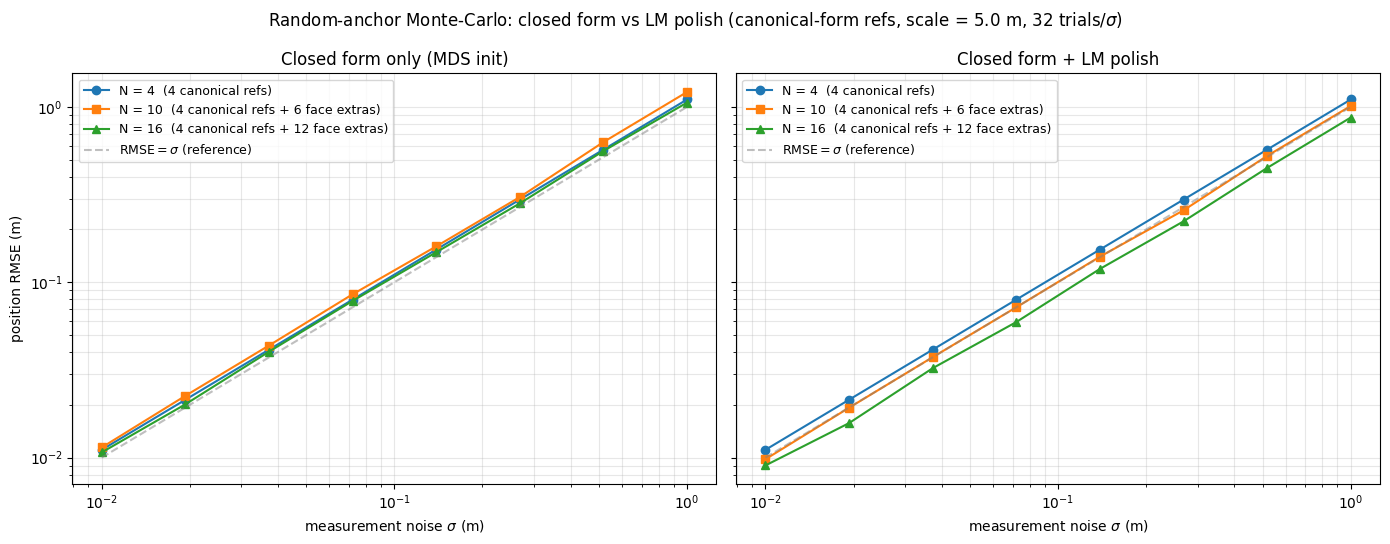

In [12]:
# Two side-by-side plots: closed-form (MDS only) and closed-form + LM polish.
# Style each N curve by its position in N_values — robust to adding entries.
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'X']
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

for ax, results, title in [
    (axes[0], results_mds, 'Closed form only (MDS init)'),
    (axes[1], results_lm,  'Closed form + LM polish'),
]:
    for idx, N in enumerate(N_values):
        rmse_mean, rmse_std = results[N]
        color  = f'C{idx % 10}'
        marker = markers[idx % len(markers)]
        extras = N - n_refs
        extras_label = f' + {extras} face extras' if extras > 0 else ''
        ax.plot(sigma_grid, rmse_mean,
                marker + '-', color=color,
                linewidth=1.5, markersize=6,
                label=f'N = {N}  ({n_refs} canonical refs{extras_label})')
    ax.plot(sigma_grid, sigma_grid, '--', color='gray', alpha=0.5,
            label=r'$\mathrm{RMSE} = \sigma$ (reference)')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'measurement noise $\sigma$ (m)')
    ax.set_title(title)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, which='both', alpha=0.3)
axes[0].set_ylabel(r'position RMSE (m)')
fig.suptitle(f'Random-anchor Monte-Carlo: closed form vs LM polish '
             f'(canonical-form refs, scale = {scale} m, {n_trials} trials/$\sigma$)')
plt.tight_layout()
plt.show()